In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
import pandas as pd

file_path = '/content/drive/MyDrive/Colab Notebooks/Datasets/Loan Eligibility Prediction.csv'
df = pd.read_csv(file_path)

print("Dataset loaded successfully. First 5 rows:")
print(df.head())

Dataset loaded successfully. First 5 rows:
   Customer_ID  Gender Married  Dependents     Education Self_Employed  \
0          569  Female      No           0      Graduate            No   
1           15    Male     Yes           2      Graduate            No   
2           95    Male      No           0  Not Graduate            No   
3          134    Male     Yes           0      Graduate           Yes   
4          556    Male     Yes           1      Graduate            No   

   Applicant_Income  Coapplicant_Income  Loan_Amount  Loan_Amount_Term  \
0              2378                 0.0            9               360   
1              1299              1086.0           17               120   
2              3620                 0.0           25               120   
3              3459                 0.0           25               120   
4              5468              1032.0           26               360   

   Credit_History Property_Area Loan_Status  
0               1    

In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         614 non-null    int64  
 1   Gender              614 non-null    object 
 2   Married             614 non-null    object 
 3   Dependents          614 non-null    int64  
 4   Education           614 non-null    object 
 5   Self_Employed       614 non-null    object 
 6   Applicant_Income    614 non-null    int64  
 7   Coapplicant_Income  614 non-null    float64
 8   Loan_Amount         614 non-null    int64  
 9   Loan_Amount_Term    614 non-null    int64  
 10  Credit_History      614 non-null    int64  
 11  Property_Area       614 non-null    object 
 12  Loan_Status         614 non-null    object 
dtypes: float64(1), int64(6), object(6)
memory usage: 62.5+ KB


,0
Customer_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
Applicant_Income,0
Coapplicant_Income,0
Loan_Amount,0
Loan_Amount_Term,0


In [14]:
print("Converting categorical features to numerical...")

# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Categorical features converted. First 5 rows of the new DataFrame:")
print(df_encoded.head())
print("\nInformation about the encoded DataFrame:")
df_encoded.info()

Converting categorical features to numerical...
Categorical features converted. First 5 rows of the new DataFrame:
   Customer_ID  Dependents  Applicant_Income  Coapplicant_Income  Loan_Amount  \
0          569           0              2378                 0.0            9   
1           15           2              1299              1086.0           17   
2           95           0              3620                 0.0           25   
3          134           0              3459                 0.0           25   
4          556           1              5468              1032.0           26   

   Loan_Amount_Term  Credit_History  Gender_Male  Married_Yes  \
0               360               1        False        False   
1               120               1         True         True   
2               120               1         True        False   
3               120               1         True         True   
4               360               1         True         True   

   Educ

In [20]:
from sklearn.utils import resample

print("Addressing class imbalance by upsampling the minority class...")

# Separate majority and minority classes based on 'Loan_Status_Y'
df_majority = df_encoded[df_encoded.Loan_Status_Y == True]
df_minority = df_encoded[df_encoded.Loan_Status_Y == False]

# Upsample minority class
df_minority_upsampled = resample(df_minority,
                                 replace=True,     # sample with replacement
                                 n_samples=len(df_majority),    # to match majority class
                                 random_state=42) # reproducible results

# Concatenate majority class with upsampled minority class
df_balanced = pd.concat([df_majority, df_minority_upsampled])

print("Class distribution after upsampling:")
print(df_balanced['Loan_Status_Y'].value_counts())

print("\nUpdating features (X) and target (y) with the balanced dataset...")
X = df_balanced.drop(['Loan_Status_Y', 'Customer_ID'], axis=1)
y = df_balanced['Loan_Status_Y']

print(f"Shape of features (X) after balancing: {X.shape}")
print(f"Shape of target (y) after balancing: {y.shape}")
print("First 5 rows of balanced features (X):")
print(X.head())
print("\nFirst 5 rows of balanced target (y):")
print(y.head())

Addressing class imbalance by upsampling the minority class...
Class distribution after upsampling:
Loan_Status_Y
True     422
False    422
Name: count, dtype: int64

Updating features (X) and target (y) with the balanced dataset...
Shape of features (X) after balancing: (844, 12)
Shape of target (y) after balancing: (844,)
First 5 rows of balanced features (X):
   Dependents  Applicant_Income  Coapplicant_Income  Loan_Amount  \
1           2              1299              1086.0           17   
2           0              3620                 0.0           25   
3           0              3459                 0.0           25   
4           1              5468              1032.0           26   
5           1              1538              1425.0           30   

   Loan_Amount_Term  Credit_History  Gender_Male  Married_Yes  \
1               120               1         True         True   
2               120               1         True        False   
3               120            

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

print("Splitting data into training and testing sets from balanced dataset...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Splitting data into training and testing sets from balanced dataset...
X_train shape: (491, 12)
X_test shape: (123, 12)
y_train shape: (491,)
y_test shape: (123,)


In [28]:
from sklearn.linear_model import LogisticRegression

print("\nRe-training a Logistic Regression model with balanced data...")
model = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
model.fit(X_train, y_train)

print("Logistic Regression model training complete.")


Re-training a Logistic Regression model with balanced data...
Logistic Regression model training complete.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Making predictions on the test set with re-trained Logistic Regression...

Evaluating re-trained Logistic Regression model performance...
Accuracy: 0.8211

Classification Report:
              precision    recall  f1-score   support

       False       0.95      0.47      0.63        40
        True       0.80      0.99      0.88        83

    accuracy                           0.82       123
   macro avg       0.87      0.73      0.76       123
weighted avg       0.85      0.82      0.80       123



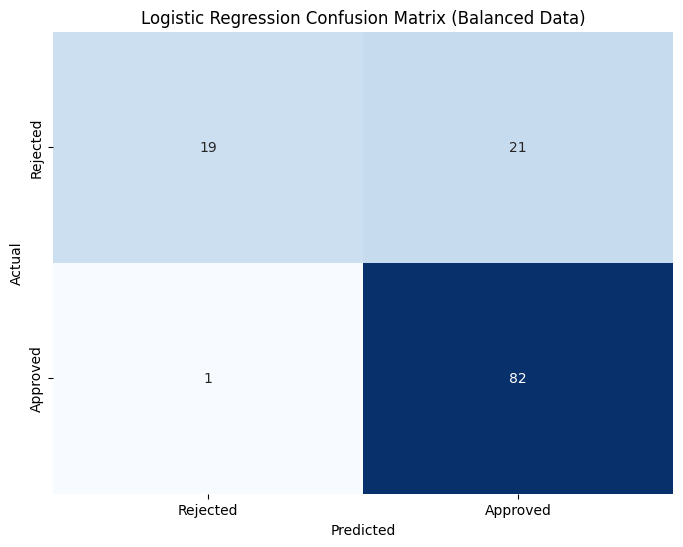

In [32]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("\nMaking predictions on the test set with re-trained Logistic Regression...")
y_pred = model.predict(X_test)

print("\nEvaluating re-trained Logistic Regression model performance...")

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Rejected', 'Approved'], yticklabels=['Rejected', 'Approved'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix (Balanced Data)')
plt.show()

In [33]:
from sklearn.tree import DecisionTreeClassifier

print("\nRe-training a Decision Tree Classifier with balanced data...")
# Initialize the Decision Tree Classifier
decision_tree_model = DecisionTreeClassifier(random_state=42)

# Train the model
decision_tree_model.fit(X_train, y_train)

print("Decision Tree model training complete.")


Re-training a Decision Tree Classifier with balanced data...
Decision Tree model training complete.


Making predictions on the test set with re-trained Decision Tree...

Evaluating re-trained Decision Tree model performance...
Decision Tree Accuracy: 0.6748

Decision Tree Classification Report:
              precision    recall  f1-score   support

       False       0.50      0.57      0.53        40
        True       0.78      0.72      0.75        83

    accuracy                           0.67       123
   macro avg       0.64      0.65      0.64       123
weighted avg       0.69      0.67      0.68       123



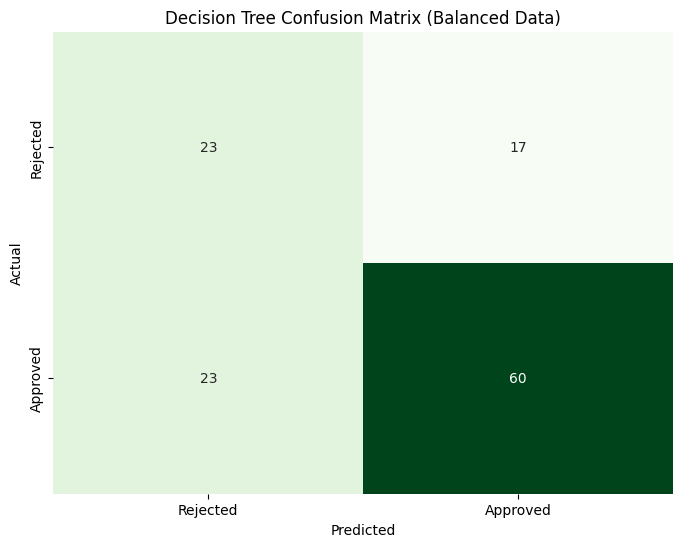

In [34]:
print("Making predictions on the test set with re-trained Decision Tree...")
y_pred_dt = decision_tree_model.predict(X_test)

print("\nEvaluating re-trained Decision Tree model performance...")

# Accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {accuracy_dt:.4f}")

# Classification Report
print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Rejected', 'Approved'], yticklabels=['Rejected', 'Approved'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix (Balanced Data)')
plt.show()